In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import datetime as dt
import opendatasets as od

In [3]:
CSV_PATH = "credit-card-transactions-dataset/credit_card_transactions.csv"
DB_PATH = "transactions.db"

In [5]:
# conn = sqlite3.connect("transactions.db")
# c = conn.cursor()

# c.executescript("""
#     CREATE TABLE IF NOT EXISTS merchants(
#         id   INTEGER PRIMARY KEY,
#         name TEXT NOT NULL
#     );

#     CREATE TABLE IF NOT EXISTS categories(
#         id          INTEGER PRIMARY KEY,
#         name        TEXT NOT NULL,
#         parent_id   INTEGER,
#         FOREIGN KEY(parent_id) REFERENCES categories(id)
#     );

#     CREATE TABLE IF NOT EXISTS transactions(
#         id           INTEGER PRIMARY KEY, 
#         date         TEXT NOT NULL, 
#         description  TEXT, 
#         amount       REAL NOT NULL, 
#         merchant_id  INTEGER, 
#         category_id  INTEGER,
#         FOREIGN KEY(merchant_id) REFERENCES merchants(id),
#         FOREIGN KEY(category_id) REFERENCES categories(id)
#     );
# """)

# conn.close()

In [10]:
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
con = sqlite3.connect("transactions.db")
df.to_sql("transactions", con, if_exists="replace", index=False)
con.commit()

pd.read_sql_query("SELECT * FROM transactions LIMIT 5", con)

,unnamed:_0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [16]:
df = pd.read_sql_query("SELECT * FROM transactions", con)
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])
df = df.drop(columns=["unnamed:_0"], errors="ignore")
df.to_sql("transactions", con, if_exists="replace", index=False)

pd.read_sql_query("SELECT * FROM transactions LIMIT 5", con)

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [20]:
df["trans_date_trans_time"] = df["trans_date_trans_time"].astype("datetime64[ns]")
df["trans_date_trans_time"].dtype

dtype('<M8[ns]')

In [12]:
con = sqlite3.connect("transactions.db")
df = pd.read_sql_query("""
    SELECT
        category,
        SUM(amt) AS total
    FROM transactions
    GROUP BY category
    ORDER BY total DESC;
""", con)

print(df.head(10))

        category        total
0    grocery_pos  14460822.38
1   shopping_pos   9307993.61
2   shopping_net   8625149.68
3  gas_transport   8351732.29
4           home   7173928.11
5      kids_pets   6503680.16
6  entertainment   6036678.56
7       misc_net   5117709.26
8       misc_pos   5009582.50
9    food_dining   4672459.44


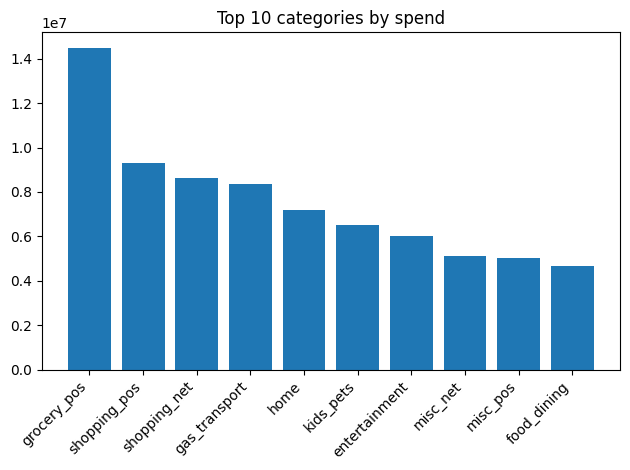

In [16]:
top10 = df.head(10).copy()
plt.figure()
plt.bar(top10["category"], top10["total"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 categories by spend")
plt.tight_layout()
plt.show()

In [19]:
df = pd.read_sql_query("""
    SELECT
        substr("trans_date_trans_time", 1, 7) AS month,
        category,
        SUM(amt) AS total
    FROM transactions
    GROUP BY month, category
    ORDER BY month, category DESC;
""", con)

print(df.head(5))

     month       category      total
0  2019-01         travel  172245.18
1  2019-01   shopping_pos  388868.18
2  2019-01   shopping_net  399951.86
3  2019-01  personal_care  178187.70
4  2019-01       misc_pos  184031.28
